<a href="https://colab.research.google.com/github/laurauguc/inside-GPT2/blob/main/Interpreting%20GPT-2%20Parameters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inside GPT-2: Following a Prompt Through the Transformer


The goal of this notebook is to develop an intuitive understanding of the Transformer architecture by examining the learned parameters of GPT-2 and following a single prompt through every stage of the model.

We will use the **GPT-2 Small** checkpoint and the prompt:

```text
The cat is chasing a
```

GPT-2's task is to predict the probability distribution over the next token in the sequence.

Rather than treating the model as a black box, we will reconstruct each computation directly from its learned parameters. At every stage, we will compare our manual implementation against the corresponding PyTorch module to verify that they produce the same intermediate activations.

For each component of the model, we will:

- Reproduce the hidden states manually using GPT-2's parameters and the outputs of previous layers.
- Verify that the manually computed activations match those produced by the official PyTorch implementation.
- Build intuition for what each equation and intermediate representation is computing and why it is needed.

By the end of the notebook, every hidden state—from the input embeddings to the final probability distribution over the vocabulary—will have been derived and interpreted.


# Part 0: Exploring the Model

Before diving into GPT-2's internals, let's load a pretrained model and tokenizer. We'll also configure PyTorch for cleaner output and inference behavior.


## 0.1 Setup

We begin by loading `GPT2Model`, which implements GPT-2's Transformer. Our goal is to understand exactly how it transforms a sequence of input tokens into contextual hidden representations.

In [ ]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import os
    if not os.path.exists("inside-GPT2"):
        !git clone https://github.com/laurauguc/inside-GPT2.git
    %cd inside-GPT2

In [ ]:
import math
import torch
from transformers import GPT2Model, GPT2Tokenizer

torch.set_printoptions(
    precision=4,
    sci_mode=False,
    linewidth=120,
)

checkpoint = "gpt2"
tokenizer = GPT2Tokenizer.from_pretrained(checkpoint)
#model = GPT2Model.from_pretrained(checkpoint)
model = GPT2Model.from_pretrained(
    checkpoint,
    use_safetensors=False,
)

model.eval()  # inference behavior (dropout off, etc.) --> ensures consistent outputs


# This is the prompt
text = "The cat is chasing a"

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

---

## 0.2 GPT-2 Small at a Glance


Now that we've loaded the model, let's get a sense of its size. We'll compute both the total number of learnable parameters and the memory required to store them.

### Number of parameters

In [ ]:
total_params = sum(
    parameter.numel() # 'numel' Returns the total number of elements in the :attr:`input` tensor.
    for parameter in model.parameters()
)

print(f"Total parameters:     {total_params:,}")

Total parameters:     124,439,808


GPT-2 Small is commonly referred to as a **124 million parameter** model. The exact parameter count of the Hugging Face implementation is:

```
124,439,808
```

The slight difference comes from rounding—the model is typically described using an approximate parameter count.

### Memory footprint

Next, let's calculate how much memory is required to store the model's parameters.

In [ ]:
def parameter_memory_bytes(model):
    return sum(
        parameter.numel() * parameter.element_size()
        for parameter in model.parameters()
    )

parameter_bytes = parameter_memory_bytes(model)

print(f"Parameter dtype:  {next(model.parameters()).dtype}")
print(f"Parameter memory: {parameter_bytes / 10**6:,.2f} MB")

Parameter dtype:  torch.float32
Parameter memory: 497.76 MB


This calculation measures **only the memory occupied by the model's parameters**. During inference, the actual memory usage is higher because it also includes:

- Intermediate activations
- Attention score matrices
- Cached key/value tensors (when generating text)
- Temporary workspace used by PyTorch operations
- Framework and device overhead (e.g., CUDA allocations)

As a result, the runtime memory footprint is typically much larger than the parameter storage alone.

---

## 0.3 High-Level Transformer Architecture

At a high level, GPT-2 transforms a sequence of input token IDs into a probability distribution over the next token in the vocabulary.

The overall computation can be summarized as follows:

```text
Token IDs                       Position IDs
   │                                │
   ▼                                ▼
Token Embedding               Position Embedding
        \                         /
         └─── Elementwise Add ───┘
                    │
                    ▼
        ┌─────────────────────────────┐
        │ Transformer Block 1         │
        │                             │
        │ • LayerNorm                 │
        │ • Multi-Head Self-Attention │
        │ • Residual Connection       │
        │ • LayerNorm                 │
        │ • MLP                       │
        │   (Linear → GELU → Linear)  │
        │ • Residual Connection       │
        └─────────────────────────────┘
                    │
                    ▼
             Transformer Block 2
                    │
                   ...
                    │
                    ▼
            Transformer Block 12
                    │
                    ▼
             Final LayerNorm
                    │
                    ▼
      Language Modeling Head
         (tied embedding weights)
                    │
                    ▼
                 Logits
```

In the remainder of this notebook, we'll trace the data as it flows through each stage of the model. Starting from the token and positional embeddings, we'll examine the intermediate activations produced by every transformer block and follow them all the way to the final logits.

The logits are the model's unnormalized scores for every token in the vocabulary. The token with the largest logit is also the token with the highest predicted probability, so if we're only interested in the model's next-token prediction, we can simply take the `argmax` of the logits without applying a softmax.

---

## 0.4 GPT-2 Configuration

The model configuration stores the hyperparameters that define GPT-2's architecture. We can access them through the model's `config` object.

In [ ]:
config = model.config

print(f"Transformer blocks: {config.n_layer}")
print(f"Hidden size:        {config.n_embd}")
print(f"Attention heads:    {config.n_head}")
print(f"Vocabulary size:    {config.vocab_size:,}")
print(f"Context length:     {config.n_positions:,}")
print(f"MLP inner size:     {config.n_inner or 4 * config.n_embd:,}")

Transformer blocks: 12
Hidden size:        768
Attention heads:    12
Vocabulary size:    50,257
Context length:     1,024
MLP inner size:     3,072


These hyperparameters describe the structure of GPT-2 Small:

- **Transformer blocks (`n_layer`)**: The number of transformer layers stacked sequentially.
- **Hidden size (`n_embd`)**: The dimensionality of each token representation throughout the model.
- **Attention heads (`n_head`)**: The number of parallel attention heads in each transformer block.
- **Vocabulary size (`vocab_size`)**: The number of tokens the model can represent and predict.
- **Context length (`n_positions`)**: The maximum sequence length the model was trained to process.
- **MLP inner size (`n_inner`)**: The hidden dimension of the feed-forward network within each transformer block, in this case `4 × n_embd`.

---

## 0.5 Inspecting the Learned Parameters


In this section, we'll inspect the model's learned parameters to better understand how GPT-2 is organized. Specifically, we'll examine:

- How parameters are named
- How parameter shapes relate to the architecture
- Where the model's parameters are concentrated

We begin by listing every parameter together with its shape and number of elements.

In [ ]:
for name, parameter in model.named_parameters():
    print(
        f"{name:50}"
        f"{str(tuple(parameter.shape)):20}"
        f"{parameter.numel():>12,}"
    )

wte.weight                                        (50257, 768)          38,597,376
wpe.weight                                        (1024, 768)              786,432
h.0.ln_1.weight                                   (768,)                       768
h.0.ln_1.bias                                     (768,)                       768
h.0.attn.c_attn.weight                            (768, 2304)            1,769,472
h.0.attn.c_attn.bias                              (2304,)                    2,304
h.0.attn.c_proj.weight                            (768, 768)               589,824
h.0.attn.c_proj.bias                              (768,)                       768
h.0.ln_2.weight                                   (768,)                       768
h.0.ln_2.bias                                     (768,)                       768
h.0.mlp.c_fc.weight                               (768, 3072)            2,359,296
h.0.mlp.c_fc.bias                                 (3072,)                    3,072
h.0.

### Parameter Naming Conventions

The parameter names mirror the hierarchical structure of the model.

- **`wte`**: Token embedding matrix (`word token embeddings`)
- **`wpe`**: Positional embedding matrix (`word position embeddings`)

The prefix **`h`** refers to the stack of Transformer blocks:

- `h.0` — first Transformer block
- `h.1` — second Transformer block
- ...
- `h.11` — twelfth (final) Transformer block

Since Python uses zero-based indexing, the twelfth block has index `11`.

Parameter names become progressively more specific as you read them from left to right. For example,

```text
attn.c_attn.weight
│    │      │
│    │      └── learnable weight matrix
│    └───────── combined QKV projection layer
└────────────── attention module
```

The `c_` prefix originates from OpenAI's original GPT implementation, where linear projections were implemented using a custom `Conv1D` class. Despite the name, these layers perform standard affine transformations rather than convolutions.

The prefix `ln_f` refers to the Final LayerNorm.


### Relating Parameter Shapes to the Architecture

The parameter shapes reflect the computations performed by each component.

| Parameter | Shape | Interpretation |
|---|---:|---|
| `wte.weight` | `(50,257, 768)` | One 768-dimensional embedding for every vocabulary token |
| `wpe.weight` | `(1,024, 768)` | One 768-dimensional embedding for every position |
| `attn.c_attn.weight` | `(768, 2,304)` | Projects hidden states into concatenated query, key, and value vectors (`3 × 768`) |
| `attn.c_proj.weight` | `(768, 768)` | Projects the concatenated attention heads back to the hidden dimension |
| `mlp.c_fc.weight` | `(768, 3,072)` | Expands the hidden representation (`4 × 768`) |
| `mlp.c_proj.weight` | `(3,072, 768)` | Projects the expanded representation back to the hidden dimension |
| LayerNorm parameters | `(768,)` | One learned scale or bias per hidden feature |

One implementation detail is worth noting. Hugging Face stores GPT-2's projection weights using a custom `Conv1D` class whose weight matrices have shape

```text
(input features, output features)
```

whereas PyTorch's `nn.Linear` stores weights as

```text
(output features, input features)
```

Although the orientation differs, both implement the same affine transformation.

### Parameter Breakdown by Component

Next, let's see how the model's parameters are distributed across its major components.

In [ ]:
from collections import defaultdict

groups = defaultdict(int)

for name, parameter in model.named_parameters():
    count = parameter.numel()

    if name.startswith("wte"):
        groups["Token embeddings"] += count
    elif name.startswith("wpe"):
        groups["Position embeddings"] += count
    elif ".attn." in name:
        groups["Attention"] += count
    elif ".mlp." in name:
        groups["MLP"] += count
    elif ".ln_" in name or name.startswith("ln_f"):
        groups["LayerNorm"] += count
    else:
        groups["Other"] += count

for group, count in groups.items():
    percentage = 100 * count / total_params
    print(f"{group:20} {count:>12,}  {percentage:6.2f}%")

Token embeddings       38,597,376   31.02%
Position embeddings       786,432    0.63%
LayerNorm                  38,400    0.03%
Attention              28,348,416   22.78%
MLP                    56,669,184   45.54%


Most of GPT-2's parameters are concentrated in three places:

1. The token embedding matrix
2. The attention projection layers across all Transformer blocks
3. The MLP layers within each Transformer block

The MLP contributes more parameters per block than the attention module because it expands the hidden representation from **768** dimensions to **3,072** dimensions before projecting it back down. As a result, the two MLP projection matrices are substantially larger than the attention projection matrices.

---

# Part 1: Input Embeddings


The first step in processing a prompt is to convert text into numerical representations that the model can operate on.

This happens in three stages:

1. Split the input text into tokens.
2. Look up a **token embedding** for each token.
3. Look up a **position embedding** for each token's position in the sequence and add it to the corresponding token embedding.

The resulting vectors serve as the input to the first Transformer block.

Embeddings map discrete tokens to points in a high-dimensional vector space. Rather than assigning arbitrary numbers to words, the model learns vectors that capture semantic and syntactic relationships from large amounts of text. Tokens that appear in similar contexts tend to have similar embeddings, so related concepts are often located near one another in this space.

A classic illustration comes from the original word2vec work, where vector arithmetic exhibits meaningful relationships such as

```text
King − Man + Woman ≈ Queen
```

Other well-known examples include

```text
Paris − France + Italy ≈ Rome
Walking − Walk + Swim ≈ Swimming
```

These examples are illustrative rather than exact, but they demonstrate that embeddings can encode relationships between words as geometric relationships between vectors.

In GPT-2 Small, every token is represented by a **768-dimensional embedding vector**. After adding the corresponding positional embedding, each token in the prompt is transformed into a 768-dimensional representation that captures both **what the token is** and **where it appears in the sequence**. These vectors form the input to the rest of the model.


> **Side note:** A good way to build intuition for embeddings is to compare the vectors of different words. Words with similar meanings or that appear in similar contexts generally have embeddings that are close together, while unrelated words tend to be farther apart. The notion of "closeness" is typically measured using **cosine similarity** or **Euclidean distance**.

The embedding process consists of five steps:

1. Tokenize the input text into **token IDs**.
2. Look up the **token embedding** for each token ID.
3. Look up the **position embedding** for each token position.
4. Add the token and position embeddings elementwise.
5. Pass the resulting vectors to the first Transformer block.

## 1.1 Split into tokens

We begin by tokenizing the input text. GPT-2 splits text into subword tokens rather than individual words.


In [ ]:
encoded = tokenizer(
    text,
    return_tensors="pt",
    add_special_tokens=False,
)

input_ids = encoded["input_ids"]
tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

print("Tokens:   ", tokens)
print("Token IDs:", input_ids[0].tolist())
print("Shape:    ", tuple(input_ids.shape))

Tokens:    ['The', 'Ġcat', 'Ġis', 'Ġchasing', 'Ġa']
Token IDs: [464, 3797, 318, 20023, 257]
Shape:     (1, 5)


Notice that some tokens begin with the character `Ġ`. This is a convention used by the GPT-2 tokenizer to indicate that the token starts immediately after a space.

For example, the token `Ġa` represents the text `" a"` (with a leading space), **not** the literal string `"Ġa"`.

In [ ]:
print(tokenizer.encode("a"))
print(tokenizer.encode(" a"))

[64]
[257]


Because GPT-2 treats leading whitespace as part of the token, `"a"` and `" a"` are different tokens and therefore have different token IDs.

## 1.2 Token Embeddings

Now let's see how a token ID is converted into its embedding vector.

We'll use the final token in our prompt, `" a"`, as an example.

First, retrieve its token ID.

In [ ]:
token_id = input_ids[0, -1]
print(token_id)

tensor(257)


GPT-2 stores all token embeddings in a single embedding matrix.

In [ ]:
embedding_table = model.wte.weight
embedding_table.shape

torch.Size([50257, 768])

The embedding table has shape

```text
(vocabulary size, hidden size)
= (50,257, 768)
```

Each row corresponds to one vocabulary token, and each column corresponds to one embedding dimension. Since the token ID uniquely identifies a row, obtaining a token's embedding is simply a matter of indexing into this matrix.


In [ ]:
token_embedding = embedding_table[token_id]
token_embedding.shape

torch.Size([768])

In [ ]:
token_embedding[:10]

tensor([-0.0506,  0.0056,  0.0471, -0.0593, -0.0626, -0.0303, -0.2725,  0.0149,  0.0298, -0.0737],
       grad_fn=<SliceBackward0>)

The resulting tensor is the **768-dimensional embedding vector** for the token `" a"` (only the first 10 values are shown above).

Conceptually, this operation is just a table lookup:

```text
Token ID
    │
    ▼
Embedding table (50,257 × 768)
    │
    ▼
768-dimensional embedding vector
```

The embedding layer in the official PyTorch implementation performs the same lookup internally. To verify our manual computation, we compare the vector obtained by indexing the embedding table directly with the output of (`model.wte`).


In [ ]:
official_embedding = model.wte(token_id)
print(torch.equal(token_embedding, official_embedding))

True


The output is `True`, confirming that our manually retrieved embedding exactly matches the activation produced by the official PyTorch implementation.

---

## 1.3 Position Embeddings

Token embeddings tell the model **what** each token is, but they do not encode **where** the token appears in the sequence. To provide this information, GPT-2 learns a separate embedding vector for every position in the context window.

As with token embeddings, obtaining a position embedding is simply a lookup into a learned embedding table.

For the final token (`" a"`), the position is determined by its index in the input sequence.


In [ ]:
position = len(input_ids[0]) - 1
print("Position:", position)

Position: 4


GPT-2 stores all position embeddings in the matrix `model.wpe.weight`.

In [ ]:
position_embedding_table = model.wpe.weight
position_embedding_table.shape

torch.Size([1024, 768])

The position embedding table has shape

```text
(context length, hidden size)
= (1,024, 768)
```

Each row corresponds to one position in the sequence (from `0` to `1,023`), and each column corresponds to one embedding dimension. The position embedding for a token is obtained by indexing the row corresponding to that token's position.

In [ ]:
position_embedding = position_embedding_table[position]
position_embedding.shape

torch.Size([768])

Conceptually, this is identical to the token embedding lookup:

```text
Position
    │
    ▼
Position embedding table (1,024 × 768)
    │
    ▼
768-dimensional position embedding
```

To verify our manual lookup, we compare it with the output of the official PyTorch embedding layer.

In [ ]:
official_embedding = model.wpe(torch.tensor(position))

print(torch.equal(position_embedding, official_embedding))

True


The output is `True`, confirming that our manually retrieved position embedding exactly matches the activation produced by the official PyTorch implementation.

---
## 1.4 Constructing the Initial Hidden States


The input to the first Transformer block is obtained by adding the token embedding and position embedding for each token.

For the final token (`" a"`), the initial hidden state is simply:

In [ ]:
hidden_state = token_embedding + position_embedding

The result is a 768-dimensional vector, matching GPT-2 Small's hidden size.


In [ ]:
len(hidden_state)

768

This elementwise addition combines information about **what the token is** (its token embedding) with **where it appears in the sequence** (its position embedding).


So far, we have computed the hidden state for only the final token. However, the first Transformer block processes the **entire sequence** at once. In particular, the self-attention mechanism for the final token attends to all preceding tokens in the prompt, so it requires the hidden states for every token in the sequence.

Rather than manually repeating the embedding lookup for every token, we'll use the official PyTorch implementation to construct the complete matrix of initial hidden states.

In [ ]:
position_ids = torch.arange(input_ids.size(1))

initial_hidden_states = (
    model.wte(input_ids) +
    model.wpe(position_ids)
)

print(initial_hidden_states.shape)

torch.Size([1, 5, 768])


This produces a tensor of shape:

```text
(batch_size, sequence_length, hidden_size)
```

Each of the five positions now has a 768-dimensional representation containing token and position information.

In the next section, we'll study a single Transformer block in isolation by following only the computation for the final token. Even so, the hidden states for every token are still required because the final token attends to the entire preceding context.

---

<a id="part-2-inside-a-transformer-block"></a>
# Part 2: Inside a Transformer Block

Now that we have constructed the initial hidden states, we can follow them through the first Transformer block.

GPT-2 Small contains 12 identical Transformer blocks stacked sequentially. Each block transforms the hidden representations while preserving their dimensionality. Since every Transformer block has the same architecture, understanding one of them provides a blueprint for understanding the rest.

We'll begin by studying the first Transformer block in isolation, following only the computation for the **final token**. This perspective makes it easier to see **when the computation requires the hidden representations of the entire sequence and when it can focus on a single token.** Although we ultimately follow only the final token, its updated representation can only be computed by attending to the hidden representations of the entire preceding context.

This is possible because we're temporarily treating the first Transformer block as though it were the only block in the model. In a stack of Transformer blocks, however, every block except the last must produce updated representations for **every token**, since those representations will be attended to again by the next block. We'll return to this distinction at the end of the section.

Let's inspect the first Transformer block.

In [ ]:
block = model.h[0]
print(block)

GPT2Block(
  (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (attn): GPT2Attention(
    (c_attn): Conv1D(nf=2304, nx=768)
    (c_proj): Conv1D(nf=768, nx=768)
    (attn_dropout): Dropout(p=0.1, inplace=False)
    (resid_dropout): Dropout(p=0.1, inplace=False)
  )
  (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (mlp): GPT2MLP(
    (c_fc): Conv1D(nf=3072, nx=768)
    (c_proj): Conv1D(nf=768, nx=3072)
    (act): NewGELUActivation()
    (dropout): Dropout(p=0.1, inplace=False)
  )
)


The block consists of four main components:

- **`ln_1`**: Layer normalization before self-attention
- **`attn`**: Causal multi-head self-attention
- **`ln_2`**: Layer normalization before the MLP
- **`mlp`**: Multilayer perceptron.

## 2.1 Pre-Attention Layer Normalization



The first operation inside every Transformer block is **layer normalization**.

LayerNorm can be understood as two separate steps:

1. **Token-wise normalization:** Each token is normalized independently using statistics computed from only that token's hidden features.
2. **Learned affine transformation:** The normalized features are rescaled and shifted using learned parameters that are shared across all tokens.

For a token with hidden state \(x\), LayerNorm first computes the mean and variance over the token's 768 hidden features:

$\hat{x}
=
\frac{x-\mu}{\sqrt{\sigma^2+\epsilon}},
$

where $\mu$ and $\sigma^2$ are the mean and variance computed **only from that token's 768-dimensional hidden representation**.

Then, a learned feature-wise scale and bias are applied:

$
\operatorname{LayerNorm}(x)
=
\gamma\odot\hat{x}+\beta.
$

The parameters $\gamma$ and $\beta$ are learned vectors of size 768. They are shared across all tokens that pass through this LayerNorm layer, meaning every token uses the same learned rescaling and shifting parameters. However, each token has its own normalization statistics.

For the final token (`" a"`), the input is one 768-dimensional vector. LayerNorm computes the mean and variance from this token alone, normalizes it, and then applies the same learned $\gamma$ and $\beta$ parameters used by every other token in the sequence.

In [ ]:
# Hidden state of the final token (" a")
x = initial_hidden_states[0, -1]

# LayerNorm parameters
gamma = block.ln_1.weight
beta = block.ln_1.bias
eps = block.ln_1.eps

# Mean and variance over the hidden dimension
mean = x.mean()
variance = x.var(correction=0)

# Normalize
x_hat = (x - mean) / torch.sqrt(variance + eps)

# Apply learned scale and bias
manual_output = gamma * x_hat + beta

# Compare against PyTorch
official_output = block.ln_1(initial_hidden_states)[0, -1]

print("Input shape: ", x.shape)
print("Output shape:", manual_output.shape)

print(
    "Maximum difference:",
    (manual_output - official_output).abs().max().item()
)

print(
    "Match:",
    torch.allclose(manual_output, official_output, atol=1e-6)
)

Input shape:  torch.Size([768])
Output shape: torch.Size([768])
Maximum difference: 8.940696716308594e-08
Match: True


The two implementations should agree up to floating-point precision.

Notes

- $\epsilon$ is a small constant added for numerical stability.
- $\odot$ denotes elementwise multiplication.
- $\gamma$ learns a per-feature scaling (controls variance).
- $\beta$ learns a per-feature shift (controls mean).

Next, we'll apply the same layer normalization to every token in the sequence.

In [ ]:
normalized_states = block.ln_1(initial_hidden_states)

print("Input shape: ", initial_hidden_states.shape)
print("Output shape:", normalized_states.shape)

Input shape:  torch.Size([1, 5, 768])
Output shape: torch.Size([1, 5, 768])


As expected, layer normalization changes the values of the hidden states but not their shape.

The learned parameters themselves have one value per hidden feature:


In [ ]:
print("Scale shape:", block.ln_1.weight.shape)
print("Bias shape: ", block.ln_1.bias.shape)

Scale shape: torch.Size([768])
Bias shape:  torch.Size([768])


Finally, let's inspect how the normalization changes the statistics of the final token.

In [ ]:
before = initial_hidden_states[0, -1]
after = normalized_states[0, -1]

print(
    f"Before: mean={before.mean().item(): .6f}, "
    f"std={before.std(unbiased=False).item(): .6f}"
)

print(
    f"After:  mean={after.mean().item(): .6f}, "
    f"std={after.std(unbiased=False).item(): .6f}"
)

Before: mean=-0.003253, std= 0.179384
After:  mean=-0.004824, std= 0.087975


Although the intermediate normalized vector $\hat{x}$ has zero mean and unit variance, the final output generally does **not**. The learned scale and bias ($\gamma$ and $\beta$) intentionally modify these statistics, allowing the model to learn the most useful distribution of activations while still benefiting from normalization.

---
## 2.2 Causal Multi-Head Self-Attention

The normalized hidden states now enter the **causal multi-head self-attention** layer.


Throughout this section, we'll reconstruct only the computation for the final token. To compute its updated representation, we still need the hidden states of every token because the final token attends to the entire preceding context. Once that attention has been computed, however, we can continue following only the final token while studying this Transformer block in isolation.

For the final token in our prompt (`" a"`), the attention mechanism determines which earlier tokens are most relevant for predicting the next token.

Let's first inspect the attention module.

In [ ]:
attn = block.attn
print(attn)

GPT2Attention(
  (c_attn): Conv1D(nf=2304, nx=768)
  (c_proj): Conv1D(nf=768, nx=768)
  (attn_dropout): Dropout(p=0.1, inplace=False)
  (resid_dropout): Dropout(p=0.1, inplace=False)
)


The attention layer contains two sets of learned parameters:

- **`c_attn`** computes the **queries (Q)**, **keys (K)**, and **values (V)**.
- **`c_proj`** projects the combined outputs of all attention heads back to the 768-dimensional hidden space.

In this section, we will manually reproduce every stage of the attention computation and verify it against the official PyTorch implementation.

> **Note:** During training, GPT-2 applies dropout after the attention weights and output projection. Since the model is in evaluation mode (`model.eval()`), dropout is disabled, making the computations deterministic.


### Understanding Queries, Keys, and Values

Before diving into the equations, it helps to build some intuition for the roles of the query, key, and value vectors.

Every token is projected into three different vectors:

- **Query (Q):** what information this token is looking for.
- **Key (K):** what information this token can provide.
- **Value (V):** the information that will be passed forward if the token is attended to.

These are all learned vectors—they are not English questions or labels. However, it can be helpful to imagine them behaving *as though* they were.

Returning to our prompt,

```text
The cat is chasing a
```

suppose we are processing the final token (`" a"`).

One attention head might behave *as though* its query were asking

> **"Which earlier token is the subject of this clause?"**

Again, this is only an intuition. The actual query is simply a learned 64-dimensional vector.

Each earlier token also has its own key and value.

| Token | Intuitive key | Intuitive value |
|-------|---------------|-----------------|
| `The` | "I'm a determiner." | Signals the start of a noun phrase. |
| `cat` | "I'm the subject." | Information that the subject is **cat**, including the contextual representation of *cat*, which may encode properties learned during training (e.g., that cats commonly chase mice). |
| `is` | "I'm an auxiliary verb." | Information that the sentence is using a progressive verb construction. |
| `chasing` | "I'm the main verb." | Information that the action is **chasing**, suggesting an object is likely to follow. |
| `a` | "I'm an article." | Information that a noun is expected next. |

The attention mechanism compares the query with every key.

If a key is a good match, that token receives a high attention weight, and its value contributes more strongly to the output.

In this example, one head might assign a high weight to `cat`, allowing information about the subject to flow into the representation of `" a"`. Another head might instead focus on the verb `chasing`, while others could attend to nearby tokens, punctuation, or longer-range dependencies.

Each attention head learns its own notion of what information is useful.

### The Query, Key, and Value Projection

GPT-2 computes the queries, keys, and values using a single linear projection.



In [ ]:
W = attn.c_attn.weight
b = attn.c_attn.bias

print(W.shape)

torch.Size([768, 2304])


The weight matrix has shape

```text
(hidden size, 3 × hidden size)
= (768, 2304)
```

Rather than storing three separate projection matrices, GPT-2 concatenates them into one larger matrix:

```text
                 2304 columns
┌────────────────────────────────────────┐
│     WQ     │     WK     │     WV       │
│   768 cols │   768 cols │   768 cols   │
└────────────────────────────────────────┘
```

We can recover the individual matrices by slicing:

In [ ]:
W_Q = W[:, :768]
W_K = W[:, 768:1536]
W_V = W[:, 1536:]

b_Q = b[:768]
b_K = b[768:1536]
b_V = b[1536:]

Each projection maps a 768-dimensional hidden state to another 768-dimensional vector.

### Multi-Head Attention

Although each projection produces a 768-dimensional vector, GPT-2 does not perform attention in one large space.

Instead, it splits each vector into **12 attention heads**, allowing different heads to learn different kinds of relationships.

The dimension of each head is therefore

$
d_{\text{head}}
=
\frac{n_{\text{embd}}}{n_{\text{head}}}
=
\frac{768}{12}
=
64.
$

In [ ]:
print(f"Number of heads:      {config.n_head}")
print(f"Head dimension:       {attn.head_dim}")

Number of heads:      12
Head dimension:       64


Each head produces:

- one 64-dimensional query vector,
- one 64-dimensional key vector,
- one 64-dimensional value vector.

During autoregressive text generation, only the newest token's **query** needs to be computed. The **keys** and **values** for earlier tokens can be cached and reused, avoiding redundant computation. Since we are following a single inference step, we will adopt the same strategy.


Next, we'll manually compute the query, keys, and values before following the rest of the attention computation step by step.

### Step 1: Compute the Query

Since we're reconstructing only the final token, we compute its **query** while computing the keys and values for every token in the sequence.


The first third of `c_attn` corresponds to the query projection.

In [ ]:
batch, seq_len, hidden = normalized_states.shape
num_heads = config.n_head
head_dim = hidden // num_heads

last_state = normalized_states[:, -1:, :]   # (batch, 1, hidden)

W_Q = attn.c_attn.weight[:, :hidden]
b_Q = attn.c_attn.bias[:hidden]

query = last_state @ W_Q + b_Q

query = query.view(
    batch,
    1,
    num_heads,
    head_dim,
).transpose(1, 2)

The official implementation performs the same projection using the `c_attn` layer.

In [ ]:
qkv = attn.c_attn(last_state)

official_output, _, _ = qkv.split(hidden, dim=2)

official_output = official_output.view(
    batch,
    1,
    num_heads,
    head_dim,
).transpose(1, 2)

Verify that the two implementations agree.

In [ ]:
print(
    "Match:",
    torch.allclose(query, official_output, atol=1e-6)
)

Match: True


### Step 2: Compute the Keys and Values

Unlike the query, the keys and values are needed for **every token** in the sequence because the final token may attend to any earlier token.

The second third of `c_attn` contains the key projection parameters, and the final third contains the value projection parameters.


In [ ]:
W_K = attn.c_attn.weight[:, hidden:2 * hidden]
b_K = attn.c_attn.bias[hidden:2 * hidden]

W_V = attn.c_attn.weight[:, 2 * hidden:]
b_V = attn.c_attn.bias[2 * hidden:]

Compute the keys manually.

In [ ]:
K = normalized_states @ W_K + b_K

K = K.view(
    batch,
    seq_len,
    num_heads,
    head_dim,
).transpose(1, 2)

Compare against the official implementation.

In [ ]:
qkv = attn.c_attn(normalized_states)

_, official_output, _ = qkv.split(hidden, dim=2)

official_output = official_output.view(
    batch,
    seq_len,
    num_heads,
    head_dim,
).transpose(1, 2)

print(
    "Match:",
    torch.allclose(K, official_output, atol=1e-6)
)

Match: True


Repeat the same procedure for the values.

In [ ]:
V = normalized_states @ W_V + b_V

V = V.view(
    batch,
    seq_len,
    num_heads,
    head_dim,
).transpose(1, 2)

qkv = attn.c_attn(normalized_states)

_, _, official_output = qkv.split(hidden, dim=2)

official_output = official_output.view(
    batch,
    seq_len,
    num_heads,
    head_dim,
).transpose(1, 2)

print(
    "Match:",
    torch.allclose(V, official_output, atol=1e-6)
)

Match: True


At this point we have

- **Query:** shape `(batch, heads, 1, head_dim)`
- **Keys:** shape `(batch, heads, seq_len, head_dim)`
- **Values:** shape `(batch, heads, seq_len, head_dim)`

These tensors contain everything needed to compute the attention scores in the next step.

### Step 3: Compute the Attention Scores

The attention scores measure how well the query matches each key.

For one attention head, the computation is

$\text{Scores}
=
\frac{QK^\top}{\sqrt{d_{\text{head}}}}.$

The matrix multiplication computes the dot product between the query and every key. A larger dot product indicates a stronger match between what the current token is looking for (the query) and what a previous token has to offer (the key).

The division by $\sqrt{d_{\text{head}}}$ prevents the dot products from growing too large as the head dimension increases, improving numerical stability.

Let's compute the attention scores.

In [ ]:
scores = torch.matmul(
    query,
    K.transpose(-2, -1),
)

scores /= math.sqrt(head_dim)

The resulting tensor has shape

In [ ]:
print(scores.shape)

torch.Size([1, 12, 1, 5])


```text
(batch, heads, 1, sequence length)
```

For our example prompt of length five, each attention head produces **five attention scores**—one for every token seen so far.

For example, one head might produce scores conceptually like

| Token | Score |
|------|------:|
| `The` | 0.4 |
| `cat` | 3.8 |
| `is` | 0.9 |
| `chasing` | 2.7 |
| `a` | 1.1 |

These numbers are **not probabilities**. They are simply compatibility scores indicating how strongly the query matches each key. Higher scores indicate stronger matches, but the values themselves are unbounded—they can be positive or negative and do not sum to one.

The next step converts these compatibility scores into attention weights using the softmax function.

### Step 4: Compute the Attention Weights

GPT-2 converts the attention scores into probabilities by applying the softmax function along the sequence dimension.

$\text{Attention Weights}
=
\operatorname{softmax}(\text{Scores}).$

Because we are computing attention only for the **final token**, there are no future tokens to mask. (When computing attention for every token simultaneously during training, GPT-2 first applies a causal mask before the softmax.)

In [ ]:
weights = torch.softmax(
    scores,
    dim=-1,
)

Let's inspect the shape.

In [ ]:
print(weights.shape)

torch.Size([1, 12, 1, 5])


Each row now forms a probability distribution over the tokens in the prompt.

Conceptually, our example scores

| Token | Score |
|------|------:|
| `The` | 0.4 |
| `cat` | 3.8 |
| `is` | 0.9 |
| `chasing` | 2.7 |
| `a` | 1.1 |

might become attention weights like

| Token | Weight |
|------|-------:|
| `The` | 0.02 |
| `cat` | 0.60 |
| `is` | 0.03 |
| `chasing` | 0.30 |
| `a` | 0.05 |

These numbers are now probabilities:

- every weight is between 0 and 1,
- the weights sum to 1,
- larger weights indicate that the corresponding token contributes more strongly to the attention output.

In this example, the attention head primarily gathers information from `cat`, while also incorporating some information from `chasing`.

### Step 5: Compute the Context Vector


The final output of an attention head is a weighted average of the value vectors.

$\text{Context}
=
\text{Attention Weights}
\times
V.$

Each attention weight determines how much of the corresponding value vector contributes to the output.

In [ ]:
context = torch.matmul(
    weights,
    V,
)

print(context.shape)

torch.Size([1, 12, 1, 64])


Instead of selecting a single token, the attention head combines information from all previous tokens. Tokens with larger attention weights contribute more strongly, while tokens with smaller weights contribute less.

The result is one **64-dimensional context vector** for each attention head.

### Step 6: Merge the Attention Heads

So far, each attention head has produced its own 64-dimensional context vector.

GPT-2 now concatenates the outputs of the 12 heads to recover the original hidden size of 768.

In [ ]:
context = context.transpose(1, 2)

context = context.reshape(
    batch,
    1,
    hidden,
)

Let's inspect the shape.

In [ ]:
print(context.shape)

torch.Size([1, 1, 768])


```text
(batch, 1, hidden size)
```

Conceptually, the merged vector contains information gathered by all twelve attention heads.

Some heads may focus on nearby tokens, others on longer-range dependencies, and others on grammatical or semantic relationships. Concatenating the heads allows the model to combine all of these learned perspectives into a single representation.


### Step 7: Apply the Output Projection

The concatenated attention heads are next passed through one final learned linear projection, `c_proj`.

This projection mixes information across the different attention heads while preserving the hidden dimension.

Manually compute the output projection.

In [ ]:
Wp = attn.c_proj.weight
bp = attn.c_proj.bias

attn_output = context @ Wp + bp

Compare against the official PyTorch implementation.

In [ ]:
official_output = attn.c_proj(context)

print(
    "Match:",
    torch.allclose(attn_output, official_output, atol=1e-6)
)

Match: True


__The attention mechanism has now produced its output for the final token.__

The successful comparison confirms that we have manually reproduced the entire attention computation:

1. Query projection
2. Key projection
3. Value projection
4. Attention score computation
5. Softmax normalization
6. Weighted aggregation of the value vectors
7. Concatenation of the attention heads
8. Output projection

---

## 2.3 First Residual Connection

The attention mechanism is now complete. The output of the attention sublayer has shape `(1, 1, 768)` and contains information gathered from the entire input sequence.

The next step is the **first residual connection**.

Unlike LayerNorm, the attention projections, or the MLP, the residual connection has **no learnable parameters**. Its only operation is an elementwise addition that combines the input to the sublayer with its output. **Because it is not a learnable layer, it is implemented directly in the `forward()` method rather than as an `nn.Module`. This is why you won't find a `ResidualConnection` module when inspecting `GPT2Block`.**

```text
GPT2Block(
  (ln_1): LayerNorm(...)
  (attn): GPT2Attention(...)
  (ln_2): LayerNorm(...)
  (mlp): GPT2MLP(...)
)
```

Instead, the residual addition is implemented directly in the `forward()` method as

```python
hidden_states = residual + attn_output
```

The residual connection is computed as

$
\text{Output}
=
\text{Input}
+
\text{Sublayer Output}.
$

The residual connection preserves the original hidden representation while incorporating the information learned by the attention mechanism. Rather than replacing what the model already knows about the token, the Transformer block **refines** that representation by adding the newly computed attention output to the original hidden state.

During training, GPT-2 applies `resid_dropout` to the attention output before performing the addition. Since we previously called `model.eval()`, dropout is disabled, so the computation reduces to a simple elementwise sum.

Let's manually compute the first residual connection.


In [ ]:
next_hidden = initial_hidden_states[:, -1:, :] + attn_output

Since the residual connection is not a standalone module, there is no separate output to compare against. Instead, we will verify this computation later when we manually reconstruct the complete `GPT2Block`. For now, we simply carry the updated hidden state forward.

The tensor shapes evolved throughout the attention computation as follows:

| Stage | Shape |
|--------|-------|
| Hidden states | `(1, 5, 768)` |
| Query | `(1, 12, 1, 64)` |
| Keys | `(1, 12, 5, 64)` |
| Attention scores | `(1, 12, 1, 5)` |
| Attention weights | `(1, 12, 1, 5)` |
| Context vectors | `(1, 12, 1, 64)` |
| Merged heads | `(1, 1, 768)` |
| Attention output | `(1, 1, 768)` |
| After residual connection | `(1, 1, 768)` |

Notice how the sequence dimension narrows during our manual reconstruction. We began with hidden states for all five tokens because the final token needed to attend to the entire sequence. Once its updated representation has been computed, we continue following only that representation. This illustrates an important property of a Transformer block: the full sequence is needed while computing attention, but once the updated representation of the final token has been produced, that single representation contains all the contextual information needed for the remainder of the block.

The resulting hidden state is now ready to enter the second LayerNorm before passing through the MLP.

## 2.4 Pre-MLP Layer Normalization

After the first residual connection, the updated hidden state passes through **another LayerNorm** before entering the MLP.

The first residual connection changed the hidden representation by incorporating information gathered from the attention mechanism. Applying LayerNorm again ensures that the MLP receives inputs with a stable distribution, improving optimization and helping maintain consistent activations throughout the network.

Recall that each GPT-2 block contains **two** LayerNorm layers:

1. **`ln_1`** normalizes the hidden states before self-attention.
2. **`ln_2`** normalizes the updated hidden states before the MLP.

The computation is identical to the LayerNorm we implemented in Section 2.1. Rather than repeating each step, we'll reuse the same procedure with the second set of learned parameters.

Let's first inspect the second LayerNorm.

In [ ]:
print(block.ln_2)

LayerNorm((768,), eps=1e-05, elementwise_affine=True)


As before, the layer contains a learned scale (`weight`) and bias (`bias`) for each of the 768 hidden dimensions.

Let's manually normalize the hidden state produced by the first residual connection.

In [ ]:
gamma = block.ln_2.weight
beta = block.ln_2.bias
eps = block.ln_2.eps

x = next_hidden

mean = x.mean(dim=-1, keepdim=True)
var = x.var(dim=-1, unbiased=False, keepdim=True)

normalized_hidden = (x - mean) / torch.sqrt(var + eps)
normalized_hidden = gamma * normalized_hidden + beta

Now compare our manual implementation against the official PyTorch implementation.

In [ ]:
official_output = block.ln_2(next_hidden)

print(
    "Match:",
    torch.allclose(
        normalized_hidden,
        official_output,
        atol=1e-6,
    ),
)

Match: True


The successful comparison confirms that we have manually reproduced the second LayerNorm. The normalized hidden state is now ready to enter the MLP, where GPT-2 performs a nonlinear transformation before applying the second residual connection.

## 2.5 Feed-Forward (MLP) Network

After the second LayerNorm, the normalized hidden state enters the **feed-forward network**, also known as the **multi-layer perceptron (MLP)**.

Unlike self-attention, which allows tokens to exchange information with one another, the MLP processes **each token independently**. Its role is to transform each token's hidden representation into a richer feature representation before passing it to the next Transformer block.

As throughout this notebook, we are only interested in predicting the **next token**.  Therefore, we only process the hidden state of the **final token**, which has shape `(1, 1, 768)`. Although GPT-2 normally applies the MLP to every token in parallel, processing only the final token produces the same next-token prediction while simplifying the computation.

Let's inspect the MLP.

In [ ]:
print(block.mlp)

GPT2MLP(
  (c_fc): Conv1D(nf=3072, nx=768)
  (c_proj): Conv1D(nf=768, nx=3072)
  (act): NewGELUActivation()
  (dropout): Dropout(p=0.1, inplace=False)
)


The MLP consists of four components:

1. **`c_fc`** ("fully connected") expands the hidden representation from 768 to 3072 dimensions.
2. **`act`** ("activation") applies the GELU activation function.
3. **`c_proj`** ("projection") projects the hidden representation back to 768 dimensions.
4. **`dropout`** randomly zeros activations during training to improve generalization.

Since the model is in evaluation mode (`model.eval()`), dropout is disabled and has no effect.

### Step 1: Fully Connected Projection (`c_fc`)

The first linear layer expands the hidden representation from 768 to 3072 dimensions.

In [ ]:
W = block.mlp.c_fc.weight
b = block.mlp.c_fc.bias

expanded_hidden = normalized_hidden @ W + b

In [ ]:
print("Weight matrix shape: ", W.shape)
print("Bias vector shape: ", b.shape)
print("Output shape: ", expanded_hidden.shape)

Weight matrix shape:  torch.Size([768, 3072])
Bias vector shape:  torch.Size([3072])
Output shape:  torch.Size([1, 1, 3072])


Compare against the official implementation.

In [ ]:
official_fc = block.mlp.c_fc(normalized_hidden)

print(
    "Match:",
    torch.allclose(
        expanded_hidden,
        official_fc,
        atol=1e-6,
    ),
)

Match: True


The larger hidden dimension gives the model additional capacity to learn more complex feature transformations before compressing the representation back to its original size.

### Step 2: GELU Activation (`act`)

Next, GPT-2 applies the **Gaussian Error Linear Unit (GELU)** activation function.

Unlike ReLU, which either keeps or discards activations, GELU smoothly scales each value according to its magnitude. GPT-2 uses the following approximation:

$
\mathrm{GELU}(x)
=
\frac{1}{2}x
\left(
1+\tanh\!\left(
\sqrt{\frac{2}{\pi}}
\left(
x+0.044715x^3
\right)
\right)
\right).
$

Apply the activation manually.

In [ ]:
import torch.nn.functional as F

activated_hidden = F.gelu(
    expanded_hidden,
    approximate="tanh",
)

activated_hidden.shape

torch.Size([1, 1, 3072])

Compare against the official implementation.

In [ ]:
official_gelu = block.mlp.act(expanded_hidden)

print(
    "Match:",
    torch.allclose(
        activated_hidden,
        official_gelu,
        atol=1e-6,
    ),
)

Match: True


### Step 3: Output Projection (`c_proj`)

Finally, the activated features are projected back to the original hidden size.

In [ ]:
W = block.mlp.c_proj.weight
b = block.mlp.c_proj.bias

mlp_output = activated_hidden @ W + b

Compare against the official implementation.

In [ ]:
official_output = block.mlp.c_proj(activated_hidden)

print(
    "Match:",
    torch.allclose(
        mlp_output,
        official_output,
        atol=1e-6,
    ),
)

Match: True


The successful comparisons confirm that we have manually reproduced the MLP computation.

The tensor shapes evolved throughout the MLP computation as follows:

| Stage | Shape |
|--------|-------|
| Input hidden state | `(1, 1, 768)` |
| Expanded representation | `(1, 1, 3072)` |
| After GELU | `(1, 1, 3072)` |
| MLP output | `(1, 1, 768)` |

The MLP has now produced an updated representation for the final token. The next step is to combine this output with the original input to the MLP using the second residual connection.

## 2.6 Second Residual Connection

The MLP computation is now complete. The output of the MLP has shape `(1, 1, 768)` and contains a richer feature representation for the final token.

As with the first residual connection, the Transformer block adds the MLP output back to the hidden state that entered the MLP.

The updated hidden state is computed as

$\text{Output}
=
\text{Input}
+
\text{MLP Output}.
$

During training, GPT-2 applies `dropout` to the MLP output before performing the addition. Since we previously called `model.eval()`, dropout is disabled, so the computation reduces to a simple elementwise sum.

Let's manually compute the second residual connection.

In [ ]:
block_output = next_hidden + mlp_output

Now compare our complete manual reconstruction of the Transformer block against the official implementation.

In [ ]:
block_output.shape

torch.Size([1, 1, 768])

In [ ]:
initial_hidden_states.shape

torch.Size([1, 5, 768])

In [ ]:
initial_hidden_states.shape

torch.Size([1, 5, 768])

In [ ]:
official_output = block(initial_hidden_states)[0][ -1:, :]

print(
    "Match:",
    torch.allclose(
        block_output,
        official_output,
        atol=1e-5,
    ),
)

Match: True


The successful comparison confirms that we have manually reconstructed the computations performed for the final token by a single GPT-2 Transformer block. If the model contained only this one block, the updated representation of the final token would be already be enough to make the next-token prediction. GPT-2, however, stacks many Transformer blocks together, each attending to earlier token representations, so before continuing we need to return to the complete sequence of hidden states.

## 2.7 Completing the Transformer Stack

We have now manually reconstructed the computation performed for the **final token** by the first GPT-2 Transformer block and verified each step against the official implementation.

By treating the first Transformer block as though it were the only block in the model, we were able to clearly distinguish **when the computation requires the hidden representations of the entire sequence and when it can focus on a single token.** Although we ultimately followed only the final token, its updated representation could only be computed by attending to the keys and values of every token in the sequence.

The same computation applies independently to every token in the sequence: each token computes its own query, attends to the keys and values of the entire sequence, and produces an updated hidden representation. If the model consisted of only this one Transformer block, the updated representation of the final token would already contain all the information needed to predict the next token.

GPT-2 Small, however, contains **12 Transformer blocks** stacked sequentially. Each Transformer block recomputes attention and rewrites the hidden representation of every token. As a result, the updated representations produced by the first block become the input to the second block, where every token again attends to the entire sequence. Only in the **final Transformer block** can we continue following just the final token once the keys and values have been computed, since there are no subsequent blocks that need the updated representations of the earlier tokens.

We therefore return to the full sequence of hidden states and apply all 12 Transformer blocks using the official implementation.

In [ ]:
hidden_states = initial_hidden_states

for block in model.h:
    hidden_states = block(hidden_states)#[0]

In [ ]:
hidden_states.shape

torch.Size([1, 5, 768])

After the twelfth and final Transformer block, the hidden states have shape `(1, 5, 768)` and contain the final contextual representation of every token in the input sequence. Since there are no further Transformer blocks that need the earlier token representations, we can now focus on the final token alone.

To predict the next token, GPT-2 uses only the hidden representation of the **final input token**, so we extract the last hidden state.

In [ ]:
final_hidden = hidden_states[:, -1:, :]
final_hidden.shape

torch.Size([1, 1, 768])

### Why so many Transformer blocks?

One way to build intuition is to think of the Transformer blocks as **successive rounds of refinement**. Rather than building a complete understanding in a single step, GPT-2 gradually refines each token's representation as it passes through the stack of Transformer blocks.

For our prompt

```text
The cat is chasing a
```

you might imagine the representation of the final token evolving like this:

**After Block 1**

> "This is an article."

↓

**After Block 5**

> "This article follows a transitive verb."

↓

**After Block 12**

> "The verb is 'chasing', so I'm probably introducing the direct object. The next token is likely a noun naming something that can be chased."

This is **not** exactly how individual Transformer blocks behave, but it provides a useful mental model. Early layers often capture more local or syntactic patterns, while deeper layers tend to encode richer semantic relationships. By the time the hidden states leave the final Transformer block, GPT-2 has finished integrating information from the **input context**.

---

<a id="part-3-producing-the-next-token"></a>
# Part 3: Producing the Next Token

By this point, we have manually reconstructed almost the entire computation performed by GPT-2. Starting from the input tokens, we followed the hidden representations through the embedding layers and each of the twelve Transformer blocks, gradually building increasingly rich contextual representations.

Throughout the notebook, we've intentionally worked with `GPT2Model`, which contains only GPT-2's Transformer. Our goal has been to understand how the model constructs contextual hidden representations, one layer at a time.

The only remaining computation inside `GPT2Model` is the **final LayerNorm** (`ln_f`). Once we've reconstructed and verified this last operation, we'll have completely reproduced the forward pass of the Transformer itself.

After that, we'll switch to `GPT2LMHeadModel`, which adds one final component—the **language modeling (LM) head**—that converts these hidden representations into vocabulary logits for next-token prediction.


## 3.1 Final Layer Normalization


The final operation performed by `GPT2Model` is one last LayerNorm (ln_f).

Although every Transformer block already contains two LayerNorm layers, this final normalization (`ln_f`) serves a different purpose. Rather than preparing the hidden states for another Transformer block, it prepares the final contextual representations for the **language modeling head**, which converts them into vocabulary logits.

Mathematically, this LayerNorm is identical to those used inside each Transformer block:

$$
\hat{x}
=
\frac{x-\mu}{\sqrt{\sigma^2+\epsilon}},
$$

followed by

$$
\operatorname{LayerNorm}(x)
=
\gamma\odot\hat{x}+\beta.
$$

The only difference is that the learned parameters now come from the model's final LayerNorm (`ln_f`) rather than from one of the Transformer blocks.

Let's manually apply the final LayerNorm to the hidden representation of the final token.


In [ ]:
x = final_hidden

gamma = model.ln_f.weight
beta = model.ln_f.bias
eps = model.ln_f.eps

mean = x.mean(dim=-1, keepdim=True)
var = x.var(dim=-1, unbiased=False, keepdim=True)

normalized_final = (x - mean) / torch.sqrt(var + eps)
normalized_final = gamma * normalized_final + beta

Now compare our manual implementation with the official PyTorch module.

In [ ]:
official_output = model.ln_f(final_hidden)

print(
    "Match:",
    torch.allclose(
        normalized_final,
        official_output,
        atol=1e-6,
    ),
)

Match: True


The successful comparison confirms that we have manually reproduced GPT-2's final LayerNorm.

Let's also inspect the tensor shapes.

In [ ]:
print("Input shape: ", final_hidden.shape)
print("Output shape:", normalized_final.shape)

Input shape:  torch.Size([1, 1, 768])
Output shape: torch.Size([1, 1, 768])


As expected, the hidden size remains unchanged:

```text
(batch, 1, hidden size)
=
(batch, 1, 768)
```

Like every previous LayerNorm, this operation changes the values of the hidden representation without changing its dimensionality.

The output of `ln_f` is the **final hidden representation** that GPT-2 uses to predict the next token. In the next section, we'll verify that this tensor exactly matches the output returned by `GPT2Model` before projecting it into the vocabulary space.

<a id="final-hidden-states-gpt2model-output"></a>
## 3.2 Final Hidden States (`GPT2Model` Output)


So far, we have manually reconstructed the entire forward pass of `GPT2Model`. Starting from the input embeddings, we followed the hidden representations through all twelve Transformer blocks and the final LayerNorm, producing the tensor `normalized_final`.

Before moving on to the language modeling head, let's verify that our manually computed hidden state exactly matches the output produced by the official `GPT2Model`.

Recall that `GPT2Model` returns the final hidden representation for every input token. Since next-token prediction depends only on the last input token, we extract the final position.

In [ ]:
official_hidden = model(input_ids).last_hidden_state[:, -1:, :]

print("Shape:", official_hidden.shape)

Shape: torch.Size([1, 1, 768])


The output has the expected shape:

```text
(batch, 1, hidden size)
=
(batch, 1, 768)
```

Now compare the official output with the hidden state we manually reconstructed.

In [ ]:
print(
    "Match:",
    torch.allclose(
        normalized_final,
        official_hidden,
        atol=1e-5,
    ),
)

Match: True


The successful comparison confirms that we have manually reproduced the complete computation performed by GPT2Model.

At this point, the model has transformed the original prompt

```The cat is chasing a```

**into a single 768-dimensional contextual representation for the final token.**

This hidden representation is the **final output** of `GPT2Model`. If you call GPT2Model, this is exactly what the model returns.

However, this is **not yet a prediction over the vocabulary**. The hidden representation lives in GPT-2's internal feature space, where each dimension encodes learned abstract features rather than individual words or tokens.

To convert these features into next-token predictions, GPT-2 adds one final component: the language modeling (LM) head.

Hugging Face packages the complete model as `GPT2LMHeadModel`, which consists of:

```text

GPT2LMHeadModel
├── GPT2Model
└── LM Head
```

From this point onward, we'll switch from `GPT2Model` to `GPT2LMHeadModel` and follow the hidden representation through the LM head to produce one logit for every token in GPT-2's vocabulary.

<a id="vocabulary-projection-language-modeling-head"></a>
## 3.3 Vocabulary Projection (Language Modeling Head)

[⬆ Return to Top](#table-of-contents)

The output of `GPT2Model` is the final hidden representation of the last input token:

```text
(batch, 1, hidden size)
=
(batch, 1, 768)
```

Although this vector summarizes everything the model has inferred from the input context, it is **not yet a prediction over the vocabulary**. GPT-2 must still convert this 768-dimensional representation into one score for every token in its vocabulary.

This is the role of the **language modeling head** (LM head). GPT-2 converts the final hidden representation into vocabulary logits using the language modeling (LM) head.

More generally, a **head** is the task-specific output layer attached to a Transformer. The Transformer itself is often called the **backbone**, since it produces the contextual hidden representations that can be reused for different tasks. Different heads can then interpret those representations in different ways.

For GPT-2, the attached head is the **language modeling (LM) head**, whose job is to convert the final hidden representation into scores over the vocabulary for next-token prediction.


```text
768
 ↓
50,257 vocabulary logits
```

Unlike many output layers, GPT-2's language modeling head **does not introduce a separate weight matrix**. Instead, it reuses the input embedding matrix. This technique is known as **weight tying**.

Earlier, the embedding matrix performed the transformation

```text
Token ID
    ↓
768-dimensional embedding
```

Now, the same matrix is used in the opposite direction:

```text
768-dimensional hidden state
           ↓
Vocabulary logits
```

The shared matrix therefore serves two complementary purposes:

- **Input:** convert token IDs into embedding vectors.
- **Output:** compare the final hidden representation against every token embedding to produce vocabulary scores.

We can verify that the language modeling head shares its weights with the input embedding layer.

Up to this point, we have been working with `GPT2Model`, which contains only the Transformer backbone. Because it does not include the language modeling head, we load the full `GPT2LMHeadModel` **to verify how the LM head is connected and to confirm that its weights are tied to the input embedding layer**. After this verification, all manual calculations will continue using the previously loaded `GPT2Model`.

In [ ]:
from transformers import GPT2LMHeadModel

lm_model = GPT2LMHeadModel.from_pretrained(checkpoint, use_safetensors=False)
lm_model.eval()

print(
    lm_model.lm_head.weight.data_ptr()
    == lm_model.transformer.wte.weight.data_ptr()
)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

True


The output is `True` confirming that both modules reference the **same underlying tensor** in memory.

Since the LM head reuses the embedding matrix, we can inspect that shared matrix directly from our existing `GPT2Model`. As an additional verification, we can confirm that the word token embedding matrix in `GPT2Model` is **identical** to the LM head weight matrix in `GPT2LMHeadModel`.

In [ ]:
# Verify that both tensors contain exactly the same values.
print(torch.equal(model.wte.weight, lm_model.lm_head.weight))

True


Let's also inspect the shared weight matrix.

In [ ]:
W = model.wte.weight

print(W.shape)

torch.Size([50257, 768])


The output is

```text
torch.Size([50257, 768])
```

The weight matrix has shape

```text
(vocabulary size, hidden size)
=
(50,257, 768)
```

where each row corresponds to the embedding vector of one vocabulary token.

### Manual Vocabulary Projection:

The language modeling head computes the **dot product** between the final hidden representation and every token embedding in the vocabulary.

For vocabulary token \(i\),

$$
\text{logit}_i = h^\top W_i,
$$

where

- $h \in \mathbb{R}^{768}$ is the final hidden representation,
- $W_i \in \mathbb{R}^{768}$ is the embedding vector of the \(i\)-th vocabulary token.

Repeating this computation for all 50,257 vocabulary tokens produces the complete logit vector:

$$
\mathbf{logits}
=
hW^\top.
$$

Notice that the weight matrix is transposed because PyTorch stores linear layer weights with shape

```text
(output features, input features)
```

so the matrix multiplication becomes

```text
(1 × 768)
    ×
(768 × 50,257)
    ↓
(1 × 50,257)
```

We can reproduce this computation manually.

In [ ]:
logits = normalized_final @ W.T

print(logits.shape)

torch.Size([1, 1, 50257])


The output has the expected shape:

```text
torch.Size([1, 1, 50257])
```

or equivalently,

```text
(batch, 1, vocabulary size)
=
(batch, 1, 50,257)
```

Now compare our manual implementation against the official language modeling head.

In [ ]:
official_logits = lm_model.lm_head(normalized_final)

print(
    "Match:",
    torch.allclose(
        logits,
        official_logits,
        atol=1e-6,
    ),
)

Match: True


The successful comparison confirms that we have manually reproduced the computation performed by GPT-2's language modeling head.

Let's also check that logits obtained by applying the entire model directly to the input_ids, as opposed to the latest layer, also matches:

In [ ]:
with torch.no_grad():
    outputs = lm_model(input_ids)


official_logits = outputs.logits[:, -1, :].squeeze()  # logits for the next token

print(official_logits.shape)

torch.Size([50257])


In [ ]:
official_logits = lm_model.lm_head(normalized_final)

print(
    "Match:",
    torch.allclose(
        logits,
        official_logits,
        atol=1e-6,
    ),
)

Match: True


### Understanding Weight Tying

During training, GPT-2 learns an embedding vector for every vocabulary token. These embeddings capture semantic and syntactic relationships between words. Rather than learning a second, unrelated output matrix, GPT-2 reuses the same embeddings when making predictions. Intuitively, the model asks:

"Which token's learned embedding most closely matches the contextual representation I've built from the input?"

Weight tying therefore makes the input and output representations live in the same feature space while also reducing the total number of parameters.


### Intuition: Measuring Compatibility

The final hidden representation is a 768-dimensional summary of the entire input context. The language modeling head asks a simple question:

> **Which token embedding is most compatible with this contextual representation?**

It answers this by computing a **dot product** between the hidden representation and every token embedding.

The dot product can be written as

$$
h \cdot W_i
=
\|h\|\,\|W_i\|\cos\theta,
$$

where $\theta$ is the angle between the two vectors.

Geometrically, the dot product measures how strongly two vectors point in the same direction. If they are closely aligned, the dot product is large. If they are nearly orthogonal, it is close to zero. If they point in opposite directions, the dot product becomes negative.

Conceptually, every token embedding can be imagined as an arrow in GPT-2's learned 768-dimensional feature space.

Cloning into 'inside-GPT2'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 24 (delta 6), reused 22 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (24/24), 2.16 MiB | 8.18 MiB/s, done.
Resolving deltas: 100% (6/6), done.
/content/inside-GPT2


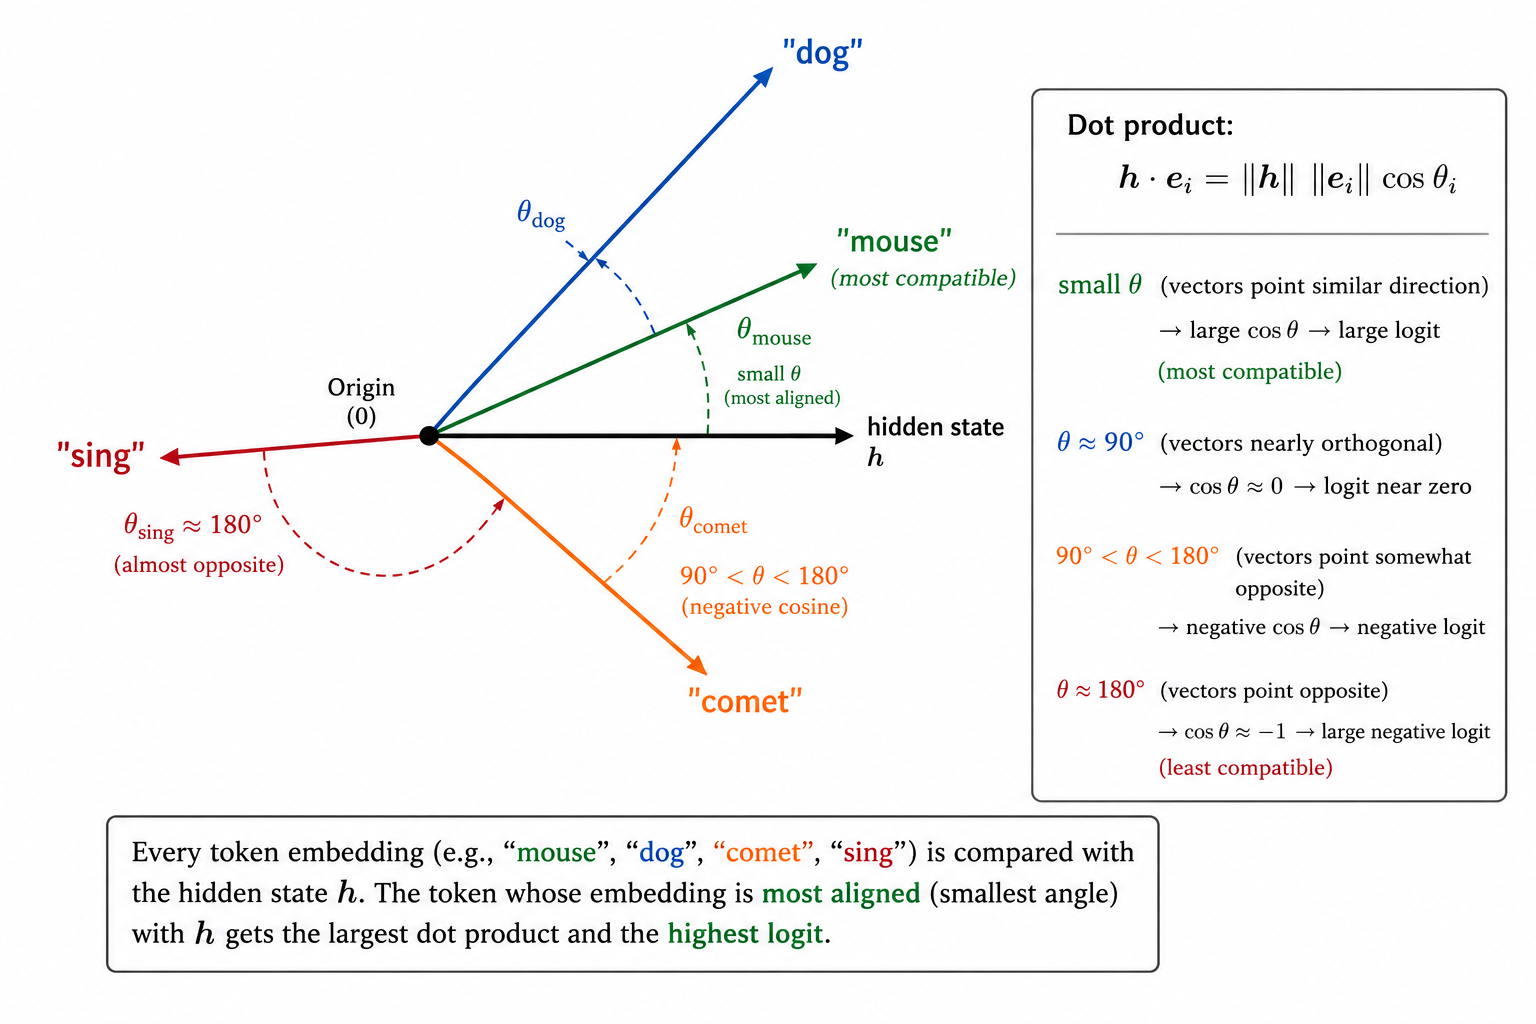

In [ ]:
from IPython.display import Image, display

display(Image("images/vectors-comparison.png", width=600))

Note: Although the actual hidden states and token embeddings live in a **768-dimensional feature space**, the figure shows them in **two dimensions** for visualization purposes. The underlying geometric intuition is the same: embeddings that point in a direction more closely aligned with the hidden representation have larger dot products and therefore receive higher logits.


The language modeling head computes one dot product for every token embedding in the vocabulary. Tokens whose embeddings are more closely aligned with the hidden representation receive larger logits, while less compatible tokens receive smaller logits.

### Why Does This Work?

The hidden representation and the token embeddings live in the **same learned feature space**. This relationship is not manually designed—it emerges during training.

During training, suppose the model repeatedly encounters the context

```text
The cat is chasing a ...
```

where the correct next token is often `"mouse"`.

The Transformer produces a hidden representation \(h\), while the language modeling head computes

$$
\text{logit}_{\text{mouse}}
=
h^\top e_{\text{mouse}}.
$$

The training objective then compares the predicted logits against the correct next token using the cross-entropy loss.

During backpropagation, gradient descent updates **both**

- the Transformer parameters, changing how the hidden representation \(h\) is computed, and
- the shared embedding matrix, changing the token embeddings themselves.

Over billions of training examples, the Transformer learns to produce hidden representations that point toward the embeddings of the correct next tokens, while the embeddings simultaneously move into positions that make the correct tokens easier to distinguish from incorrect alternatives.

After training, contexts that should predict `"mouse"` naturally produce hidden representations that are strongly aligned with the `"mouse"` embedding, giving it a large logit.

At this stage, GPT-2 has produced one **logit** for every token in its vocabulary. These values are still **unnormalized scores** rather than probabilities. In the next section, we'll apply the softmax function to convert these logits into a probability distribution over the vocabulary and identify the model's predicted next token.

<a id="next-token-logits"></a>
## 3.4 Next-Token Logits

[⬆ Return to Top](#table-of-contents)

The language modeling head has now produced one **logit** for every token in GPT-2's vocabulary.

```text
(batch, 1, vocabulary size)
=
(batch, 1, 50,257)
```

Each element of this tensor corresponds to one token in GPT-2's vocabulary and represents the model's score for predicting that token as the next token in the sequence.

Importantly, these values are **logits**, not probabilities.

Let's inspect the logits produced by the language modeling head.

In [ ]:
print(logits.shape)

torch.Size([1, 1, 50257])


Since the batch size and sequence length are both one, we can remove these dimensions for easier inspection.

In [ ]:
logits = logits.squeeze()

print(logits.shape)

torch.Size([50257])


Each entry now corresponds to the score assigned to one vocabulary token.

Let's inspect a few of the logits.

In [ ]:
print(logits[:10])

tensor([-105.9235, -105.6786, -108.5752, -107.6404, -109.3819, -109.1619, -107.3034, -106.8242, -105.3122, -106.2051],
       grad_fn=<SliceBackward0>)


Notice that logits are **unnormalized scores rather than probabilities**. Their absolute values have no intrinsic meaning: **adding or subtracting the same constant** from every logit leaves the resulting softmax **probabilities unchanged**. What matters are the **differences between logits**.

**At this point, GPT-2 has assigned a score to every token in its vocabulary. The next step is simply to choose the token with the highest score.**

<a id="predicting-next-token"></a>

## 3.5 Predicting the Next Token

[⬆ Return to Top](#table-of-contents)

We have now reconstructed the entire forward pass of GPT-2. Starting from tokenization, we manually computed the embeddings, positional encodings, Transformer blocks, final LayerNorm, and language modeling head, ultimately producing one logit for every token in GPT-2's vocabulary.

The final prediction is surprisingly simple: **choose the token with the largest logit.**

In [ ]:
next_token_id = logits.argmax()

print(next_token_id)
print(tokenizer.decode([next_token_id]))

tensor(3797)
 cat


For our prompt

```text
The cat is chasing a
```

GPT-2 predicts

```text
cat
```

This result may seem surprising. Many people would instinctively expect **" mouse"** to follow this prompt. Yet GPT-2 assigns the highest score to **" cat"** instead.




Does this mean GPT-2 believes that cats usually chase other cats?

Not necessarily.

Remember that GPT-2 is **not trying to determine what is true about the world.** GPT-2 predicts the continuation that best matches the statistical patterns in its training data, not necessarily the one that best reflects common-sense reasoning.

To understand why GPT-2 chose **" cat"**, we need to look beyond the single highest prediction and examine the other likely continuations.

Up to this point, we have reconstructed exactly how GPT-2 computes its next-token prediction. The remaining sections focus on interpreting that prediction by examining the model's ranking of candidate tokens and the probabilities derived from the logits.

<a id="beyond-top-prediction"></a>

## 3.6 Looking Beyond the Top Prediction

[⬆ Return to Top](#table-of-contents)

The top prediction only tells us **which token ranked first**. It does not tell us **how much better** that token was than the alternatives.

To inspect GPT-2's preferences, let's sort the logits from largest to smallest.

In [ ]:
topk = torch.topk(logits, k=10)

print(topk.indices)
print(topk.values)

tensor([ 3797,  3290, 33039,   582, 22746,  1862,  2415, 42143, 28583,  2042])
tensor([-97.0135, -97.1900, -97.6133, -97.6323, -97.8574, -98.1677, -98.2992, -98.3211, -98.3832, -98.4156],
       grad_fn=<TopkBackward0>)


The first tensor contains the vocabulary IDs of the ten highest-scoring tokens, while the second contains their corresponding logits.

Vocabulary IDs are not particularly informative by themselves, so let's convert them back into readable text.

In [ ]:
for token_id, logit in zip(topk.indices, topk.values):
    token = tokenizer.decode([token_id])
    print(f"{token!r:>12} : {logit.item():8.3f}")

      ' cat' :  -97.013
      ' dog' :  -97.190
 ' squirrel' :  -97.613
      ' man' :  -97.632
   ' rabbit' :  -97.857
    ' young' :  -98.168
    ' woman' :  -98.299
   ' kitten' :  -98.321
    ' stray' :  -98.383
    ' black' :  -98.416


Notice that GPT-2 assigns very similar logits to many plausible continuations.

Although **" cat"** ranks first, it is competing against numerous other reasonable next words. The model is therefore choosing among many plausible continuations rather than identifying one uniquely correct answer.

Where does the expected continuation **" mouse"** rank?

In [ ]:
mouse_id = tokenizer.encode(" mouse")[0]

sorted_ids = torch.argsort(official_logits.squeeze(), descending=True)

rank = (sorted_ids == mouse_id).nonzero(as_tuple=True)[0].item() + 1

print("Rank:", rank)
print("Logit:", official_logits.squeeze()[mouse_id].item())

Rank: 28
Logit: -99.06784057617188


For this prompt, **" mouse"** ranks **28th** out of GPT-2's entire vocabulary of **50,257** tokens.

At first glance, ranking 28th might seem disappointing. However, among more than fifty thousand possible tokens, this still indicates that GPT-2 considers **" mouse"** to be a highly plausible continuation.

The remaining question is **how much less likely** GPT-2 considers **" mouse"** than **" cat"**. Logits alone are difficult to interpret because they are arbitrary scores. To answer that question, we convert the logits into probabilities.

<a id="converting-logits-to-probabilities"></a>

## 3.7 Converting Logits to Probabilities


[⬆ Return to Top](#table-of-contents)

Logits determine the **ordering** of GPT-2's predictions, but they do not directly express **how confident** the model is.

To convert logits into probabilities, GPT-2 applies the **softmax** function.

In [ ]:
# Convert logits to probabilities
probabilities = torch.softmax(logits, dim=0)

The resulting probabilities satisfy two important properties:

- Every probability lies between 0 and 1.
- The probabilities sum to 1.

We can verify this directly.

In [ ]:
print(f"Lowest probability:  {probabilities.min().item():.4f}")
print(f"Highest probability: {probabilities.max().item():.4f}")
print(f"Sum of probabilities: {probabilities.sum().item():.4f}")

Lowest probability:  0.0000
Highest probability: 0.0423
Sum of probabilities: 1.0000


Now let's compare the probabilities assigned to the ten highest-ranked tokens.

In [ ]:
print("Top 10 predicted tokens:\n")

for token_id in topk.indices:
    token = tokenizer.decode([token_id.item()])
    logit = logits[token_id].item()
    probability = probabilities[token_id].item()

    print(
        f"{token!r:>12} | "
        f"logit = {logit:7.3f} | "
        f"probability = {100 * probability:6.3f}%"
    )

Top 10 predicted tokens:

      ' cat' | logit = -97.013 | probability =  4.231%
      ' dog' | logit = -97.190 | probability =  3.546%
 ' squirrel' | logit = -97.613 | probability =  2.322%
      ' man' | logit = -97.632 | probability =  2.279%
   ' rabbit' | logit = -97.857 | probability =  1.819%
    ' young' | logit = -98.168 | probability =  1.334%
    ' woman' | logit = -98.299 | probability =  1.170%
   ' kitten' | logit = -98.321 | probability =  1.144%
    ' stray' | logit = -98.383 | probability =  1.075%
    ' black' | logit = -98.416 | probability =  1.041%


We can also inspect the probability assigned to **" mouse"**.

In [ ]:
mouse_token = " mouse"
mouse_id = tokenizer.encode(mouse_token)[0]

print(f"\n'mouse' token:\n")
print(f"Token ID: {mouse_id}")
print(f"Token: {tokenizer.decode([mouse_id])!r}")
print(f"Logit: {logits[mouse_id].item():.3f}")
print(f"Probability: {100 * probabilities[mouse_id].item():.3f}%")


'mouse' token:

Token ID: 10211
Token: ' mouse'
Logit: -99.068
Probability: 0.542%


These probabilities may initially seem surprisingly small. After all, even the most likely token receives only about **4% probability**.

This is perfectly normal.

GPT-2 is choosing among **50,257** possible vocabulary tokens. Even in a relatively constrained context, there are dozens—or even hundreds—of plausible continuations. Consequently, the probability mass is distributed across many different tokens rather than concentrated on a single answer.

Seen from this perspective, **0.54%** is actually quite substantial. If every vocabulary token were equally likely, each would receive only

$
\frac{1}{50,257}
\approx
0.002\%.
$

A probability of **0.54%** is therefore roughly **270 times larger** than that uniform baseline, indicating that GPT-2 considers **" mouse"** much more plausible than an average vocabulary token.

Several factors help explain why **" cat"** still ranks above **" mouse"**:

- GPT-2 predicts the **most statistically likely continuation**, not the most logically correct one.
- The prompt **"The cat is chasing a"** is genuinely ambiguous. Many different nouns can naturally follow depending on the surrounding context.
- GPT-2 Small has **124 million parameters** and is considerably less capable than modern language models. Larger models often rank **" mouse"** much higher for prompts like this.

The key takeaway is that GPT-2 learns a **probability distribution** over its entire vocabulary. The predicted next token is simply the highest-probability outcome under that distribution, while many other continuations remain plausible.

## 3.8 Sentence Completion

So far, we've focused on predicting **one token at a time**. In practice, however, language models generate entire sequences. They do this by repeatedly applying the same next-token prediction process we have reconstructed throughout this notebook.

Generation is therefore an autoregressive process:

1. Predict the next token.
2. Append the predicted token to the existing sequence.
3. Feed the extended sequence back into the model.
4. Repeat until a stopping criterion is reached.

In this example, we'll begin with the ten highest-ranked candidate tokens from the previous section. Each candidate serves as an alternative starting point for generation. After fixing this first token, we'll continue generating the remainder of the sentence using **greedy decoding**, selecting the highest-scoring token at every subsequent step until a period is produced.

The procedure is therefore:

- Compute the top-10 next-token logits.
- Decode the corresponding tokens.
- For each token:
  - append it to the prompt,
  - repeatedly predict the next token using greedy decoding,
  - stop when a period is generated,
  - compare the completed sentences.

> **Note**
>
> Throughout this notebook we use **greedy decoding**, which always selects the highest-scoring token at each step. Modern language models often use **sampling** strategies instead, introducing controlled randomness that can produce more diverse and natural generations. Greedy decoding is sufficient here because it keeps the generation process deterministic, allowing us to focus on how autoregressive generation works rather than on decoding strategies.

In [ ]:
import pandas as pd

# Compute next-token logits
with torch.no_grad():
    outputs = lm_model(input_ids)

next_token_logits = outputs.logits[:, -1, :]

# Top 10 first-token candidates
topk = torch.topk(next_token_logits, k=10)

results = []

for rank, token_id in enumerate(topk.indices.squeeze(), start=1):

    # Append the chosen first token
    generated = torch.cat(
        [input_ids, token_id.view(1, 1)],
        dim=1
    )

    # Continue generation greedily until reaching a period
    while True:

        with torch.no_grad():
            outputs = lm_model(generated)

        next_id = outputs.logits[:, -1, :].argmax(dim=-1, keepdim=True)

        generated = torch.cat([generated, next_id], dim=1)

        text = tokenizer.decode(
            generated.squeeze(),
            skip_special_tokens=True
        )

        if text.rstrip().endswith("."):
            break

        # Safety stop
        if generated.shape[1] > input_ids.shape[1] + 50:
            break

    results.append({
        "Rank": rank,
        "First token": repr(tokenizer.decode([token_id.item()])),
        "Completion": text,
    })

df = pd.DataFrame(results)

print(df.to_markdown(index=False))

|   Rank | First token   | Completion                                                                              |
|-------:|:--------------|:----------------------------------------------------------------------------------------|
|      1 | ' cat'        | The cat is chasing a cat.                                                               |
|      2 | ' dog'        | The cat is chasing a dog, and the dog is chasing a cat.                                 |
|      3 | ' squirrel'   | The cat is chasing a squirrel, and the squirrel is chasing a cat.                       |
|      4 | ' man'        | The cat is chasing a man who is trying to steal his car.                                |
|      5 | ' rabbit'     | The cat is chasing a rabbit, and the rabbit is chasing a cat.                           |
|      6 | ' young'      | The cat is chasing a young girl, who is trying to escape from a man who is chasing her. |
|      7 | ' woman'      | The cat is chasing a woman who is try

The completed sentences reveal an important property of autoregressive language models. Although each sentence begins with a different first token, GPT-2 is able to continue every branch with fluent, grammatically well-formed text. Once the initial token is fixed, each subsequent prediction naturally adapts to the evolving context, extending the sequence one token at a time.

At the same time, fluency does not guarantee semantic consistency. For example, one of GPT-2's generated completions is

> *The cat is chasing a man who is trying to steal his car.*

The sentence is grammatically correct and reads naturally, yet its most straightforward interpretation is problematic: the pronoun *his* refers to *the man*, implying that he is trying to steal his own car. Humans immediately recognize this inconsistency because we combine linguistic understanding with common-sense knowledge about the world. GPT-2, by contrast, has learned statistical patterns of language rather than an explicit model of ownership, theft, or pronoun reference. As a result, it can generate text that is locally fluent while still containing semantic inconsistencies.

This concludes our manual reconstruction of GPT-2's forward pass. Starting from raw text, we followed every computation performed by the model—from tokenization and embeddings through self-attention, feed-forward networks, LayerNorm, the language modeling head, and finally autoregressive text generation. Despite the apparent complexity of modern language models, every generated sentence ultimately arises from repeatedly applying the same next-token prediction process we have reconstructed throughout this notebook.

<a id="conclusion"></a>
# Part 4: Conclusion

<a id="recap-of-the-forward-pass"></a>
## 4.1 Recap of the Forward Pass

[⬆ Return to Top](#table-of-contents)

In this notebook, we followed a single prompt through every stage of GPT-2 Small's forward pass, manually reconstructing the computations performed by the model from its learned parameters.

Beginning with the prompt

```text
The cat is chasing a
```

we first tokenized the input, looked up its token and positional embeddings, and combined them to produce the initial hidden representations.

We then stepped inside a single Transformer block and reproduced each component of its computation:

- Layer normalization
- Query, key, and value projections
- Attention scores
- Multi-head self-attention
- Residual connections
- Pre-MLP layer normalization
- Feed-forward (MLP) network
- A second residual connection

At every stage, we verified our manually computed activations against the Hugging Face implementation, confirming that our calculations exactly matched those produced by GPT-2.

After understanding the computations within a single Transformer block, we returned to the complete model and applied all twelve blocks sequentially. We then reconstructed the final layer normalization, applied the language modeling head to project the final hidden representation into the vocabulary space, and converted the resulting logits into a probability distribution over the entire vocabulary.

Rather than treating GPT-2 as a black box, we traced the complete journey of a prompt—from raw text to the prediction of its next token—and saw how every stage of the forward pass contributes to that prediction.

---

<a id="key-takeaways"></a>
## 4.2 Key Takeaways

[⬆ Return to Top](#table-of-contents)

Although GPT-2 contains over 120 million learned parameters, the forward pass is built from a surprisingly small collection of mathematical operations repeated throughout the network. By reconstructing these computations ourselves, several important ideas become much clearer.

### GPT-2 is built from simple operations

Transformers often appear intimidating because of their scale, but each component is built from familiar linear algebra operations:

- matrix multiplication
- vector addition
- normalization
- dot products
- softmax
- nonlinear activation functions

The complexity of GPT-2 comes not from complicated algorithms, but from repeatedly applying these simple operations using parameters learned from enormous amounts of text.

### Hidden states are the language of the Transformer

After tokenization and embedding, GPT-2 no longer operates on words—it operates entirely on vectors.

Every module in the Transformer receives a tensor of hidden states and returns another tensor of exactly the same shape:

```text
(batch_size, sequence_length, hidden_size)
```

Each layer transforms these representations, gradually enriching them with contextual information while preserving the overall structure of the data. Only after the final Transformer block do we select the hidden state corresponding to the last token and project it into the vocabulary to predict what comes next.

This consistent flow of hidden states is one of the key ideas that makes the Transformer architecture both elegant and scalable.

### Attention gathers information from context

The self-attention mechanism allows each token to gather information from earlier tokens in the sequence.

For every token, GPT-2 computes a query vector that represents what information it is looking for. It compares this query with the key vectors of all previous tokens, converts those similarities into attention weights using the softmax function, and finally produces a weighted combination of the corresponding value vectors.

Rather than copying information from a single earlier token, attention allows each token to build a contextual representation by combining information from many different positions in the sequence.

### Transformer blocks progressively refine representations

As hidden states pass through the stack of Transformer blocks, they become increasingly informative.

Each block contributes additional contextual information while residual connections preserve useful information from earlier layers. Although every block has exactly the same architecture, each has learned different parameters and therefore performs a different transformation.

By the final Transformer block, the hidden representation of the last token contains everything GPT-2 has extracted from the preceding context that is useful for predicting the next token.

### Every module has a clear purpose

Although the intermediate activations inside GPT-2 are high-dimensional tensors that cannot be interpreted directly, each component of the architecture performs a well-defined role.

- **The embedding layers** establish the model's initial representation of each token. They encode both the identity of the token and its position in the sequence, placing tokens that occur in similar contexts close together in the embedding space.

- **Layer normalization** keeps the hidden representations well-scaled before the major computations in each Transformer block, helping the network remain stable.

- **Self-attention** gathers information from earlier tokens in the sequence. It allows each token to update its representation using the parts of the context that are most relevant.

- **The MLP** interprets and refines the contextual information gathered by attention. It processes each token independently, learning increasingly rich feature representations before passing them to the next Transformer block.

- **Residual connections** preserve information from earlier layers while allowing each block to incrementally improve the hidden representations, rather than replacing them entirely.

- **The language modeling head** converts the final hidden representation into a score (logit) for every token in the vocabulary, from which the model predicts the next token.

Understanding these individual components makes the overall architecture much easier to reason about.

### Prediction is just the final step

Perhaps one of the most surprising observations is that GPT-2's final prediction is produced by a single matrix multiplication.

Once the Transformer has constructed a sufficiently informative hidden representation, generating logits over the entire vocabulary is simply a projection into the embedding space followed by a softmax.

Almost all of the model's intelligence lies in constructing that final hidden representation.

<a id="gpt-2-as-a-window-into-modern-language-models"></a>
## 4.3 GPT-2 as a Window into Modern Language Models

[⬆ Return to Top](#table-of-contents)

One of the reasons GPT-2 remains such a valuable educational model is that it acts as a window into the behavior of modern language models. Although it is much smaller than today's frontier models, many of the characteristics that define contemporary LLMs are already present—they are simply easier to observe.

Perhaps the biggest surprise in this notebook came at the very end.

Given the prompt

```text
The cat is chasing a
```

many readers—including myself—would naturally expect the next token to be **" mouse"**. Instead, GPT-2 assigned the highest probability to **" cat"**, while **" mouse"** ranked only **28th**.

At first glance, this seems like a mistake. "The cat is chasing a mouse" feels like the most natural continuation. Yet GPT-2 assigned higher probabilities to several other completions, including one that simply repeats the word *cat*.

This result highlights an important property of language models. GPT-2 is not searching for the "correct" continuation of a sentence, nor is it reasoning about cats, mice, or the physical world. Instead, it computes a probability distribution over every token in its vocabulary based on statistical patterns learned from its training data. The highest-ranked prediction is simply the token that the model estimates is most likely to appear next.

Looking through the model's predictions reveals both its strengths and its limitations. Every completion is grammatically correct, demonstrating that GPT-2 has learned an impressive representation of English syntax. At the same time, several of the highest-ranked completions are semantically unusual or describe implausible situations. The model has clearly learned how language is used, but that does not necessarily imply a coherent understanding of the world that language describes.

This distinction is closely related to the idea of **stochastic parrots**, introduced by Emily Bender, Timnit Gebru, and colleagues. They argue that language models can generate remarkably fluent text by learning statistical regularities from enormous text corpora, without possessing the kind of grounded understanding that humans often associate with language. GPT-2 provides a concrete demonstration of the underlying observation: fluent language alone should not be mistaken for complete understanding.

Ironically, these limitations become more difficult to recognize as language models become larger. Modern LLMs better simulate knowledge, reasoning abilities, and generate far more convincing responses than GPT-2. Their fluency can create the impression of a coherent understanding of the world, yet they still exhibit what researchers have described as **jagged intelligence**—remarkable competence on some tasks alongside surprising failures on others. The underlying Transformer architecture is fundamentally the same; the models have simply become much larger, been trained on vastly more data, and learned richer statistical representations of language.

For this reason, GPT-2 remains an excellent educational model. Its simplicity makes both its successes and its shortcomings easier to observe. By manually reconstructing its forward pass, we've seen exactly how a Transformer converts raw text into a probability distribution over the next token through embeddings, attention, feed-forward networks, and linear projections. In doing so, we've also gained insight into many of the behaviors that continue to characterize today's most advanced language models.

Understanding GPT-2, therefore, is about much more than understanding a model released in 2019. It provides a foundation for understanding the architecture, capabilities, and limitations of the Transformer-based language models that continue to shape modern AI.

<a id="bibliography"></a>
# Bibliography

[⬆ Return to Top](#table-of-contents)

The following references provide the theoretical foundations, implementation details, and broader context for the concepts explored throughout this notebook.

- **Vaswani, A., et al. (2017). _Attention Is All You Need._** Introduces the Transformer architecture, including self-attention, multi-head attention, positional encoding, and the encoder-decoder framework that inspired all modern Transformer-based language models.  
  Paper: https://arxiv.org/abs/1706.03762
  
- **Radford, A., Narasimhan, K., Salimans, T., & Sutskever, I. (2018). _Improving Language Understanding by Generative Pre-Training._** Introduces the original GPT architecture (GPT-1). Most of the architectural concepts reconstructed in this notebook originate from this paper.  
  Paper: https://cdn.openai.com/research-covers/language-unsupervised/language_understanding_paper.pdf

- **Radford, A., et al. (2019). _Language Models are Unsupervised Multitask Learners._** Introduces GPT-2, and explains differences to GPT-1 architecture. The **GPT-2 Small** checkpoint analyzed throughout this notebook is taken from this work.  
  Paper: https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf

- **Bender, E. M., Gebru, T., McMillan-Major, A., & Mitchell, M. (2021). _On the Dangers of Stochastic Parrots: Can Language Models Be Too Big?_** Presents an influential critique of large language models, arguing that fluent language generation should not be confused with genuine understanding. The discussion in Section 4.3 references this perspective when interpreting GPT-2's behavior.  
  Paper: https://doi.org/10.1145/3442188.3445922

- **Hugging Face Transformers – GPT-2 Documentation.** Provides the implementation details of the `GPT2LMHeadModel`, parameter names, and model architecture used throughout this notebook to reconstruct GPT-2 from its learned weights.  
  https://huggingface.co/docs/transformers/main/model_doc/gpt2

- **Andrej Karpathy. _microGPT._** Excellent educational walkthrough that rebuilds GPT2-style language models from first principles, emphasizing intuition and implementation details
  https://karpathy.github.io/2026/02/12/microgpt/

- **Jay Alammar. _The Illustrated GPT-2._** An intuitive visual explanation of GPT-2, attention, and language generation that complements the mathematical treatment presented in this notebook.  
  https://jalammar.github.io/illustrated-gpt2/